In [1]:
from imports import *
from preprocessing_util import get_column_groups, get_transformers
import shap
import mlflow

### Loading subset of test data

--(
SELECT top 50 *
  FROM [bank_projects].[db_owner].[test_data]
  where target = 1
  order by newid()
--  ) as t1 
--union 
--select * from
--(
--SELECT top 50 *
--FROM [bank_projects].[db_owner].[test_data]
--where target = 0
--order by newid() ) as t2

In [2]:
query = "select * from train_data"
train_data = sql_connect(query)
X_train = train_data.drop(columns=['TARGET'])
y_train = train_data['TARGET']
del train_data
X_train.head()

Connection to SQL Server established successfully.
Connection closed.


,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,DEBT_TO_INCOME,AVERAGE_EXTERNAL_RATING,N_DOCUMENTS_PROVIDED,ADDITIONAL_DOC_PROVIDED,TOT_PREV_APP,APPROVED_RATIO,REFUSED_RATIO,CANCELLED_RATIO,UNUSED_RATIO,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_RATING_CLIENT,YEARS_BIRTH,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE,ORG_GROUP,OCCUPATION_TYPE_GROUPED,EDUCATION_LEVEL
0,F,0,0,0,0.909091,0.4045,1,True,0,0.0,0.0,0.0,0.0,Unaccompanied,Working,Single / not married,House / apartment,2,54.91,1.88,25.36,9.68,1.22,Self-Employed,WhiteCollar/Admin,Higher Academic
1,M,0,1,0,5.334971,0.1513,1,True,0,0.0,0.0,0.0,0.0,Unaccompanied,Working,Married,House / apartment,2,26.01,1.14,0.67,5.97,4.41,Self-Employed,Labour/LowSkill,Medium Education
2,F,0,1,0,3.938567,0.3395,1,True,0,0.0,0.0,0.0,0.0,Unaccompanied,Pensioner,Separated,House / apartment,2,56.44,-0.00,23.97,1.66,3.21,Unknown/Other,NonActive,Medium Education
3,F,0,1,0,2.231920,0.7154,1,True,0,0.0,0.0,0.0,0.0,Unaccompanied,Working,Widow,House / apartment,2,65.42,6.66,0.94,11.83,-0.00,Unknown/Other,Technical/Skilled,Medium Education
4,F,1,1,0,5.084746,0.2553,1,True,0,0.0,0.0,0.0,0.0,Unaccompanied,Working,Married,House / apartment,2,32.68,3.83,9.24,5.12,1.30,Public Service,WhiteCollar/Admin,Medium Education


In [ ]:
query = '''
--select * from  (
SELECT top 50 *
  FROM [bank_projects].[db_owner].[test_data]
  where target = 1
  order by newid()
--  ) as t1 
--union 
--select * from
--(
--SELECT top 50 *
--FROM [bank_projects].[db_owner].[test_data]
--where target = 0
--order by newid() ) as t2
'''
test_data = sql_connect(query)
X_test = test_data.drop(columns=['TARGET'])
y_test = test_data['TARGET']
del test_data
X_test.head()

Connection to SQL Server established successfully.
Connection closed.


,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,DEBT_TO_INCOME,AVERAGE_EXTERNAL_RATING,N_DOCUMENTS_PROVIDED,ADDITIONAL_DOC_PROVIDED,TOT_PREV_APP,APPROVED_RATIO,REFUSED_RATIO,CANCELLED_RATIO,UNUSED_RATIO,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_RATING_CLIENT,YEARS_BIRTH,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE,ORG_GROUP,OCCUPATION_TYPE_GROUPED,EDUCATION_LEVEL
0,F,0,1,1,4.512080,0.2873,1,True,0,0.0,0.0,0.0,0.0,"Spouse, partner",Working,Married,House / apartment,2,29.02,1.45,13.25,6.57,1.95,Agriculture,Labour/LowSkill,Medium Education
1,F,0,1,0,3.400000,0.4103,1,True,0,0.0,0.0,0.0,0.0,Unaccompanied,Commercial associate,Single / not married,House / apartment,2,28.77,0.53,24.91,2.63,4.49,Business,WhiteCollar/Admin,Higher Academic
2,F,0,0,0,2.665000,0.5962,1,True,0,0.0,0.0,0.0,0.0,Unaccompanied,Pensioner,Single / not married,House / apartment,3,68.70,-0.00,33.38,12.82,4.12,Unknown/Other,NonActive,Medium Education
3,F,0,1,0,8.768160,0.5622,1,True,0,0.0,0.0,0.0,0.0,Unaccompanied,State servant,Civil marriage,House / apartment,3,29.19,0.57,12.90,8.64,1.68,Education,WhiteCollar/Admin,Higher Academic
4,F,0,1,0,6.102041,0.6153,1,True,0,0.0,0.0,0.0,0.0,Unaccompanied,Commercial associate,Married,House / apartment,2,29.53,9.21,2.66,9.47,2.19,Healthcare,Technical/Skilled,Medium Education


In [4]:
mlflow.set_tracking_uri("http://127.0.0.1:5000/") 
pipeline = mlflow.sklearn.load_model("models:/Credit Risk Model/2")

In [5]:
from sklearn import set_config
set_config(display='diagram')
pipeline  


Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('numeric_passthrough',
                                                  'passthrough',
                                                  ['DEBT_TO_INCOME',
                                                   'YEARS_EMPLOYED',
                                                   'YEARS_LAST_PHONE_CHANGE',
                                                   'YEARS_REGISTRATION',
                                                   'REFUSED_RATIO',
                                                   'YEARS_BIRTH',
                                                   'CNT_CHILDREN',
                                                   'N_DOCUMENTS_PROVIDED',
                                                   'REGION_RATING_CLIENT',
                                                   'CANCELLED_RATIO',
                                                   'YEARS_ID_PUBLISH',
                                                   'AVERAGE_EXTERNAL_RATING',
                                                   'TOT_PREV_APP'...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=50, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [6]:
transformer = pipeline.named_steps["transformer"]
model = pipeline.named_steps["model"]

In [7]:
X_test_transformed = transformer.transform(X_test)

In [8]:
all_feature_names = transformer.get_feature_names_out()

In [9]:
all_feature_names[:15]

array(['numeric_passthrough__DEBT_TO_INCOME',
       'numeric_passthrough__YEARS_EMPLOYED',
       'numeric_passthrough__YEARS_LAST_PHONE_CHANGE',
       'numeric_passthrough__YEARS_REGISTRATION',
       'numeric_passthrough__REFUSED_RATIO',
       'numeric_passthrough__YEARS_BIRTH',
       'numeric_passthrough__CNT_CHILDREN',
       'numeric_passthrough__N_DOCUMENTS_PROVIDED',
       'numeric_passthrough__REGION_RATING_CLIENT',
       'numeric_passthrough__CANCELLED_RATIO',
       'numeric_passthrough__YEARS_ID_PUBLISH',
       'numeric_passthrough__AVERAGE_EXTERNAL_RATING',
       'numeric_passthrough__TOT_PREV_APP',
       'numeric_passthrough__UNUSED_RATIO',
       'numeric_passthrough__APPROVED_RATIO'], dtype=object)

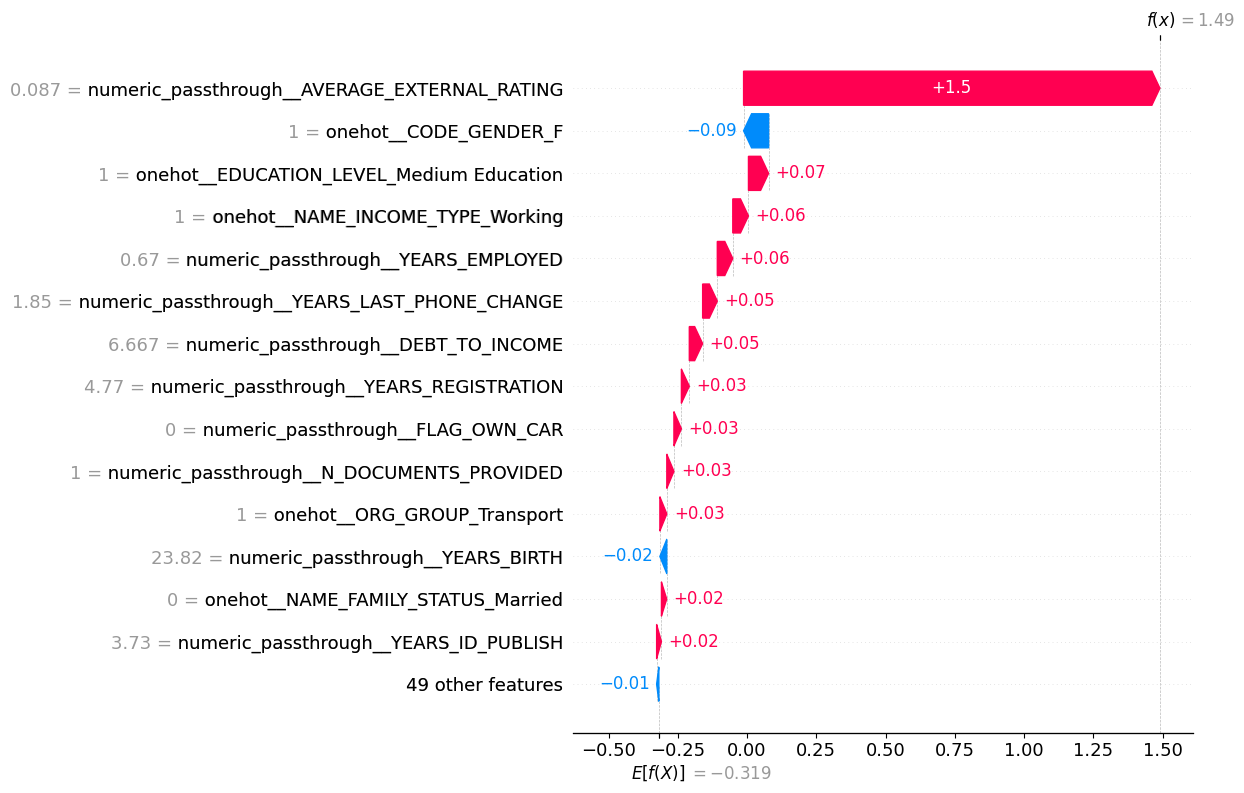

In [11]:
import shap



# 1. Choose a single test record to explain (e.g., index 0)


# 2. Get the transformer and the model from your pipeline
transformer = pipeline.named_steps['transformer']
model = pipeline.named_steps['model']

X_train_trans = np.array(transformer.transform(X_train), dtype=np.float32)

# Build the SHAP explainer on NUMERIC data
explainer = shap.Explainer(model, masker=X_train_trans, algorithm="auto", feature_names=all_feature_names)

# Now transform a row/sample to explain (as float)
i = 0  # or any other index you want
X_row = X_test.iloc[[15]]
X_row_trans = transformer.transform(X_row)
X_row_trans = np.array(X_row_trans, dtype=np.float32)

# Get SHAP values for that sample
shap_values = explainer(X_row_trans)

# 6. Plot the waterfall plot for this sample
shap.plots.waterfall(shap_values[0], max_display=15)  # Shows top 15 features by impact


In [13]:
query = '''
--select * from  (
SELECT  *
  FROM [bank_projects].[db_owner].[test_data]
--  ) as t1 
--union 
--select * from
--(
--SELECT top 50 *
--FROM [bank_projects].[db_owner].[test_data]
--where target = 0
--order by newid() ) as t2
'''
test_data = sql_connect(query)
X_test = test_data.drop(columns=['TARGET'])
y_test = test_data['TARGET']
del test_data
X_test.head()

Connection to SQL Server established successfully.
Connection closed.


,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,DEBT_TO_INCOME,AVERAGE_EXTERNAL_RATING,N_DOCUMENTS_PROVIDED,ADDITIONAL_DOC_PROVIDED,TOT_PREV_APP,APPROVED_RATIO,REFUSED_RATIO,CANCELLED_RATIO,UNUSED_RATIO,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_RATING_CLIENT,YEARS_BIRTH,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE,ORG_GROUP,OCCUPATION_TYPE_GROUPED,EDUCATION_LEVEL
0,F,0,0,0,1.861333,0.5774,1,True,0,0.0,0.0,0.0,0.0,Unaccompanied,Commercial associate,Married,House / apartment,2,46.62,3.81,4.68,1.40,8.93,Business,WhiteCollar/Admin,Medium Education
1,F,0,0,1,1.600000,0.3427,0,False,0,0.0,0.0,0.0,0.0,Unaccompanied,State servant,Married,House / apartment,3,24.70,1.36,9.84,3.11,1.00,Healthcare,Technical/Skilled,Medium Education
2,M,0,0,0,1.000000,0.4808,1,True,1,0.0,1.0,0.0,0.0,Unaccompanied,Commercial associate,Married,House / apartment,1,26.44,5.13,26.02,6.28,4.22,Business,Technical/Skilled,Medium Education
3,F,0,0,0,6.428947,0.6171,1,True,0,0.0,0.0,0.0,0.0,Unaccompanied,Working,Single / not married,Municipal apartment,1,33.71,15.36,11.50,12.28,4.21,Public Service,NonActive,Medium Education
4,F,1,1,2,3.792000,0.6267,1,True,0,0.0,0.0,0.0,0.0,Unaccompanied,Commercial associate,Civil marriage,House / apartment,2,34.49,5.05,2.22,13.10,8.36,Healthcare,WhiteCollar/Admin,Higher Academic


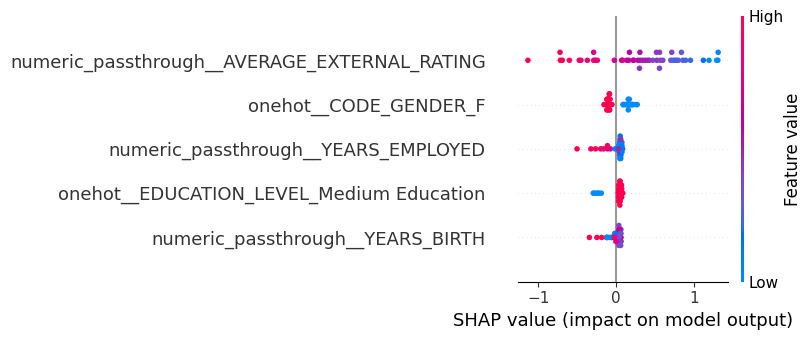

In [19]:


X_test_trans = np.array(transformer.transform(X_test), dtype=np.float32)

# Build the SHAP explainer on NUMERIC data
explainer = shap.TreeExplainer(model,  feature_names=all_feature_names)

# Now transform a row/sample to explain (as float)
i = 0  # or any other index you want
X_row = X_test.iloc[[15]]
X_row_trans = transformer.transform(X_row)
X_row_trans = np.array(X_row_trans, dtype=np.float32)

# Get SHAP values for that sample
shap_values = explainer.shap_values(X_test_transformed)

# Step 5: Global explanation
shap.summary_plot(shap_values, X_test_transformed, plot_type='dot', feature_names=all_feature_names, max_display=5)
